# Fase 13 — Visualización final: LISA, Getis-Ord Gi*, superposición y zonas prioritarias
DataJam Bogotá 2026 · pipeline `agent.md`

In [1]:
import os
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt

if os.path.exists("data"):
    BASE = os.path.abspath(".")
else:
    BASE = os.path.abspath(os.path.join(os.getcwd(), ".."))
FIG_DIR = os.path.join(BASE, "outputs", "figures")
os.makedirs(FIG_DIR, exist_ok=True)
SILVER = os.path.join(BASE, 'data', 'silver')
GOLD = os.path.join(BASE, 'data', 'gold')
plt.rcParams['figure.dpi'] = 110

gdf_upz = gpd.read_parquet(os.path.join(SILVER, 'territorio', 'upz.parquet')).reset_index(drop=True)
master_upz = pd.read_parquet(os.path.join(GOLD, 'modelos', 'ranking_upz.parquet'))
gdf = gdf_upz.merge(master_upz, on=['cod_upz', 'nombre_upz', 'area_km2'], how='left')

lisa = pd.read_parquet(os.path.join(GOLD, 'estadistica_espacial', 'moran_local', 'lisa_local.parquet'))
gistar = pd.read_parquet(os.path.join(GOLD, 'estadistica_espacial', 'hotspots_gistar', 'gistar.parquet'))
lisa_upz = lisa[lisa['unidad'] == 'UPZ'].copy()
gistar_upz = gistar[gistar['unidad'] == 'UPZ'].copy()
print(gdf.shape, lisa_upz.shape, gistar_upz.shape)

(112, 29) (672, 6) (672, 6)


## 1. Mapa LISA — deficit_aseo_relativo y densidad_puntos_criticos_km2

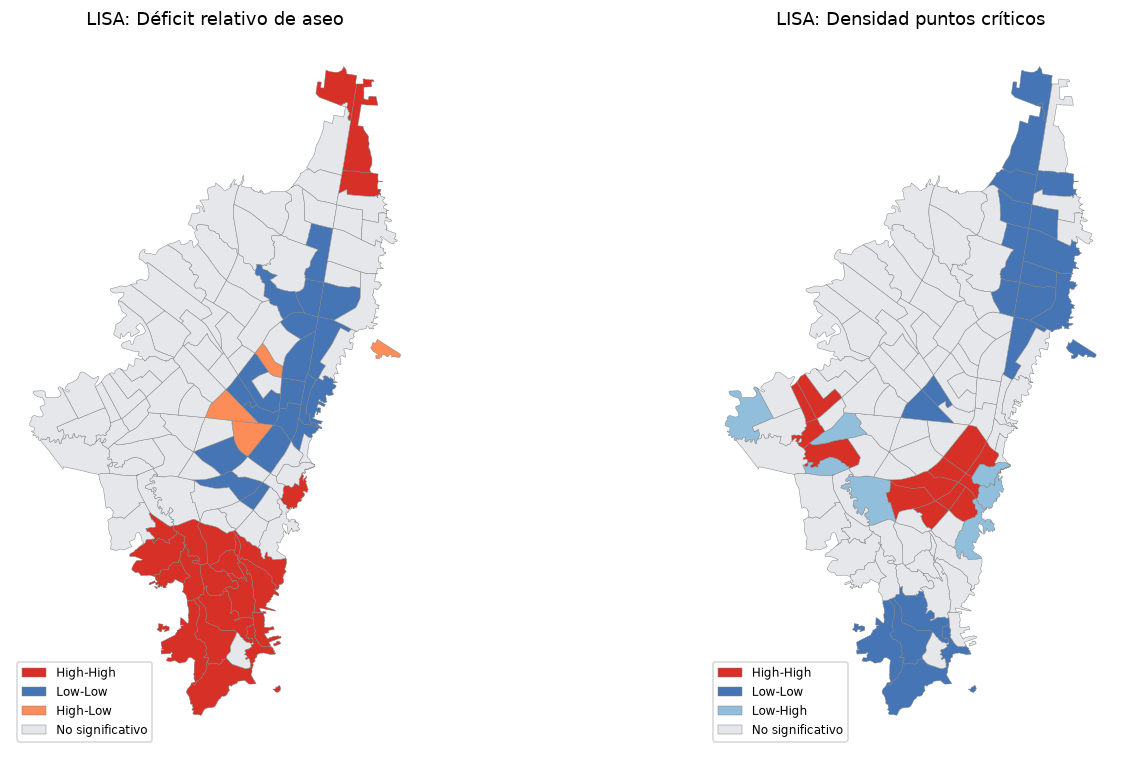

In [2]:
COLORES_LISA = {'High-High': '#d73027', 'Low-Low': '#4575b4', 'High-Low': '#fc8d59',
                 'Low-High': '#91bfdb', 'No significativo': '#e5e7eb'}

fig, axes = plt.subplots(1, 2, figsize=(15, 7))
for ax, var, titulo in zip(axes, ['deficit_aseo_relativo', 'densidad_puntos_criticos_km2'],
                             ['LISA: Déficit relativo de aseo', 'LISA: Densidad puntos críticos']):
    sub = lisa_upz[lisa_upz['variable'] == var].set_index('idx')
    gdf_v = gdf.copy()
    gdf_v['cluster'] = gdf_v.index.map(sub['cluster'])
    for cluster, color in COLORES_LISA.items():
        subset = gdf_v[gdf_v['cluster'] == cluster]
        if len(subset) > 0:
            subset.plot(ax=ax, color=color, edgecolor='grey', linewidth=0.3, label=cluster)
    ax.set_title(titulo)
    ax.axis('off')
    ax.legend(loc='lower left', fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'fig_01_lisa.png'), dpi=110)
plt.show()

## 2. Mapa Getis-Ord Gi\* — hotspots/coldspots

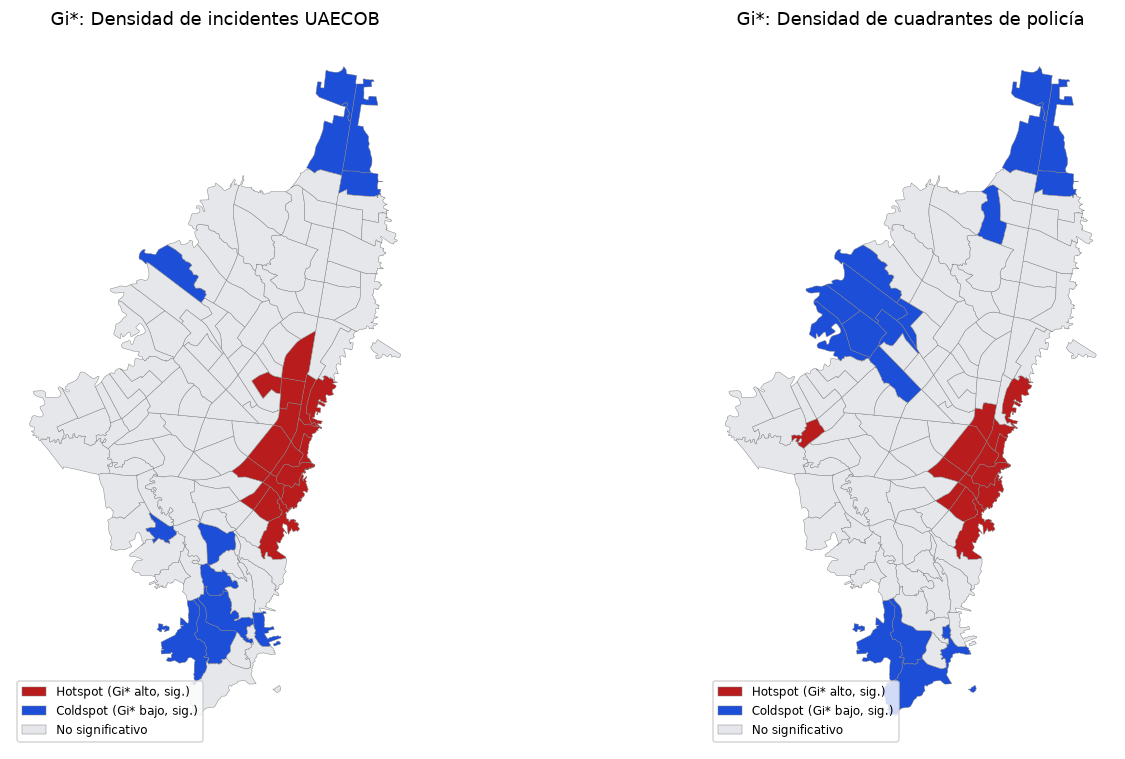

In [3]:
COLORES_GI = {'Hotspot (Gi* alto, sig.)': '#b91c1c', 'Coldspot (Gi* bajo, sig.)': '#1d4ed8', 'No significativo': '#e5e7eb'}

fig, axes = plt.subplots(1, 2, figsize=(15, 7))
for ax, var, titulo in zip(axes, ['densidad_incidentes_km2', 'densidad_cuadrantes_km2'],
                             ['Gi*: Densidad de incidentes UAECOB', 'Gi*: Densidad de cuadrantes de policía']):
    sub = gistar_upz[gistar_upz['variable'] == var].set_index('idx')
    gdf_v = gdf.copy()
    gdf_v['tipo'] = gdf_v.index.map(sub['tipo'])
    for tipo, color in COLORES_GI.items():
        subset = gdf_v[gdf_v['tipo'] == tipo]
        if len(subset) > 0:
            subset.plot(ax=ax, color=color, edgecolor='grey', linewidth=0.3, label=tipo)
    ax.set_title(titulo)
    ax.axis('off')
    ax.legend(loc='lower left', fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'fig_02_gistar.png'), dpi=110)
plt.show()

## 3. Superposición de variables (bivariado): déficit alto Y puntos críticos altos

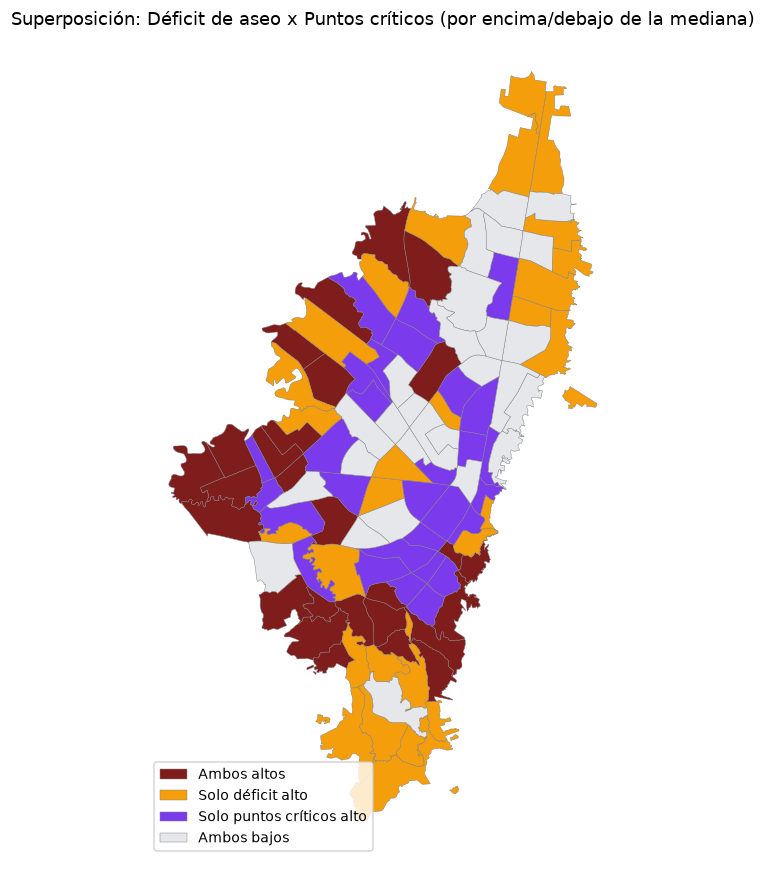

superposicion
Solo puntos críticos alto    29
Solo déficit alto            29
Ambos altos                  27
Ambos bajos                  27
Name: count, dtype: int64


In [4]:
gdf['deficit_alto'] = gdf['deficit_aseo_relativo'] > gdf['deficit_aseo_relativo'].median()
gdf['puntos_altos'] = gdf['densidad_puntos_criticos_km2'] > gdf['densidad_puntos_criticos_km2'].median()

def categoria(row):
    if row['deficit_alto'] and row['puntos_altos']:
        return 'Ambos altos'
    elif row['deficit_alto']:
        return 'Solo déficit alto'
    elif row['puntos_altos']:
        return 'Solo puntos críticos alto'
    return 'Ambos bajos'

gdf['superposicion'] = gdf.apply(categoria, axis=1)
COLORES_SUP = {'Ambos altos': '#7f1d1d', 'Solo déficit alto': '#f59e0b', 'Solo puntos críticos alto': '#7c3aed', 'Ambos bajos': '#e5e7eb'}
fig, ax = plt.subplots(figsize=(8, 8))
for cat, color in COLORES_SUP.items():
    subset = gdf[gdf['superposicion'] == cat]
    if len(subset) > 0:
        subset.plot(ax=ax, color=color, edgecolor='grey', linewidth=0.3, label=cat)
ax.set_title('Superposición: Déficit de aseo x Puntos críticos (por encima/debajo de la mediana)')
ax.axis('off')
ax.legend(loc='lower left', fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'fig_03_superposicion.png'), dpi=110)
plt.show()
print(gdf['superposicion'].value_counts())

## 4. Mapa final — zonas prioritarias (índice de vulnerabilidad compuesta)

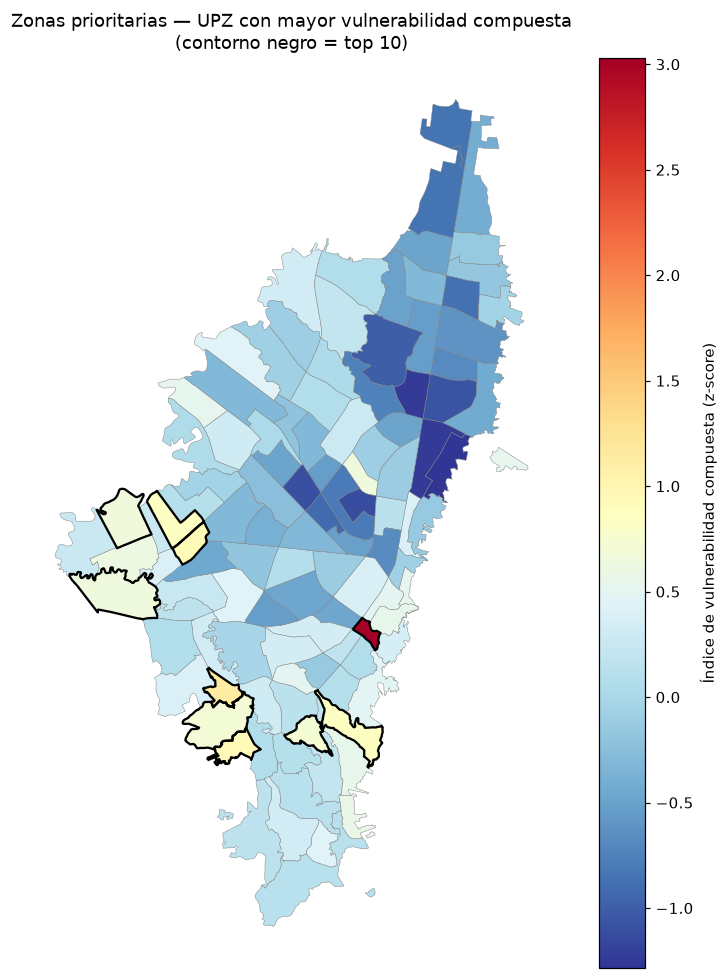

In [5]:
fig, ax = plt.subplots(figsize=(9, 9))
gdf.plot(column='idx_vulnerabilidad_compuesta', cmap='RdYlBu_r', legend=True, ax=ax,
         edgecolor='grey', linewidth=0.3, legend_kwds={'label': 'Índice de vulnerabilidad compuesta (z-score)'})
top10_idx = gdf.sort_values('idx_vulnerabilidad_compuesta', ascending=False).head(10)
top10_idx.boundary.plot(ax=ax, color='black', linewidth=1.5)
ax.set_title('Zonas prioritarias — UPZ con mayor vulnerabilidad compuesta\n(contorno negro = top 10)')
ax.axis('off')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'fig_04_zonas_prioritarias.png'), dpi=110)
plt.show()

## 5. Mapa de delitos por localidad (DAILoc solo trae localidad, no UPZ)

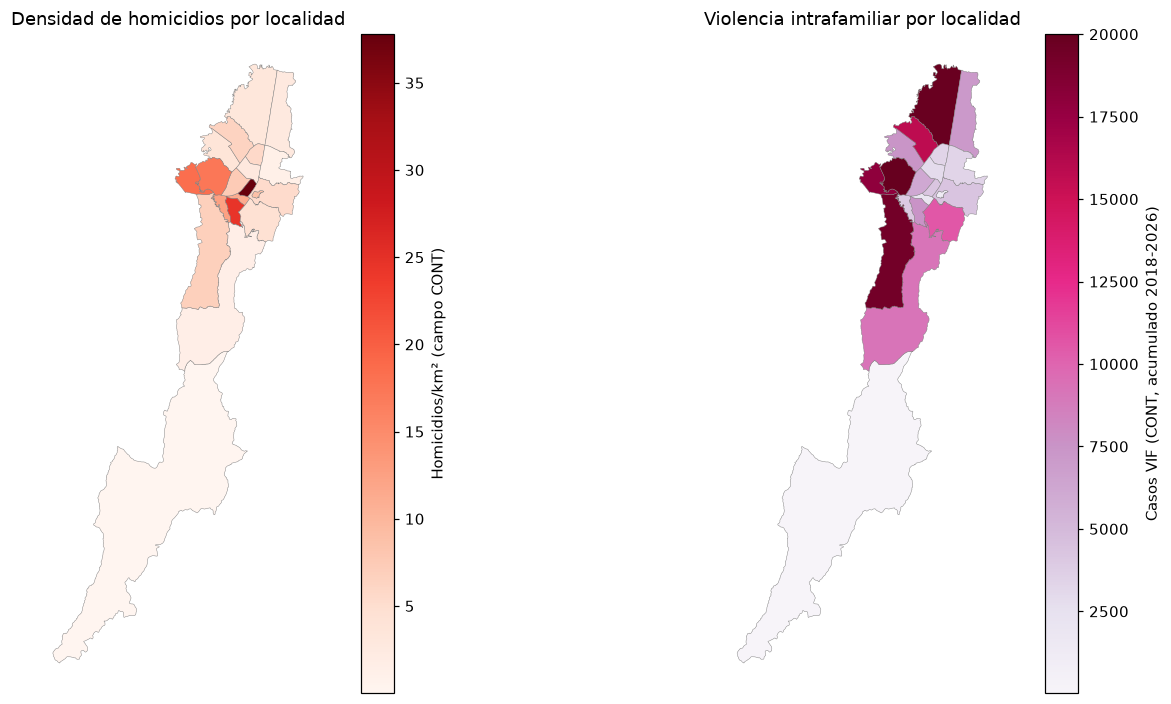

In [6]:
gdf_loc = gpd.read_parquet(os.path.join(SILVER, 'territorio', 'localidades.parquet')).reset_index(drop=True)
master_loc = pd.read_parquet(os.path.join(GOLD, 'modelos', 'dataset_hipotesis_localidad.parquet'))
gdf_loc_m = gdf_loc.merge(master_loc, on=['cod_localidad', 'nombre_localidad', 'area_km2'], how='left')

fig, axes = plt.subplots(1, 2, figsize=(15, 6.5))
gdf_loc_m.plot(column='densidad_homicidios_km2', cmap='Reds', legend=True, ax=axes[0],
               edgecolor='grey', linewidth=0.3, legend_kwds={'label': 'Homicidios/km² (campo CONT)'})
axes[0].set_title('Densidad de homicidios por localidad')
gdf_loc_m.plot(column='violencia_intrafamiliar_cont', cmap='PuRd', legend=True, ax=axes[1],
               edgecolor='grey', linewidth=0.3, legend_kwds={'label': 'Casos VIF (CONT, acumulado 2018-2026)'})
axes[1].set_title('Violencia intrafamiliar por localidad')
for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'fig_05_delitos_localidad.png'), dpi=110)
plt.show()

## 6. Mapa de infraestructura formal de aseo (cestas + contenedores)

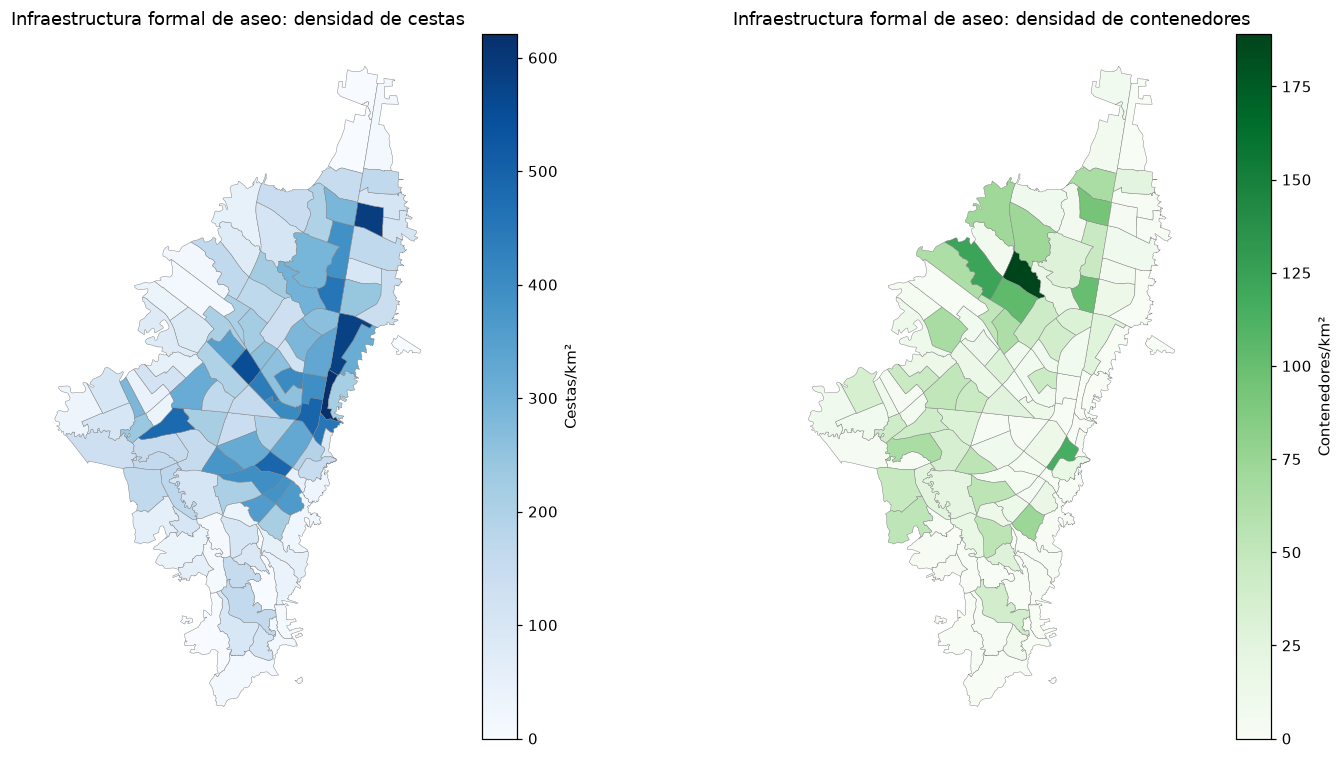

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 7))
gdf.plot(column='densidad_cestas_km2', cmap='Blues', legend=True, ax=axes[0],
         edgecolor='grey', linewidth=0.3, legend_kwds={'label': 'Cestas/km²'})
axes[0].set_title('Infraestructura formal de aseo: densidad de cestas')
gdf.plot(column='densidad_contenedores_km2', cmap='Greens', legend=True, ax=axes[1],
         edgecolor='grey', linewidth=0.3, legend_kwds={'label': 'Contenedores/km²'})
axes[1].set_title('Infraestructura formal de aseo: densidad de contenedores')
for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'fig_06_infraestructura_aseo.png'), dpi=110)
plt.show()